<a href="https://colab.research.google.com/github/slowlyP/AI_26/blob/main/03_AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1%EB%B0%8F%EB%B6%84%EC%84%9D(%EC%86%A1%EB%AA%85%EA%B7%BC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split


# 데이터 로드 및 전처리
(train_input, train_target), (test_input, test_target) =\
  keras.datasets.fashion_mnist.load_data()

train_scaled = train_input /255.0 # 정규화 (0~1 사이값)

# 데이터 분할 (8:2)비율
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

# CNN을 위한 차원 변경
train_scaled = train_scaled.reshape(-1,28,28,1)
val_scaled = val_scaled.reshape(-1,28,28,1)



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
print("훈련데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터 :")
print(test_input.shape, test_target.shape)
print("검증데이터 :")
print(val_scaled.shape, val_target.shape)

훈련데이터 :
(48000, 28, 28, 1) (48000,)
테스트데이터 :
(10000, 28, 28) (10000,)
검증데이터 :
(12000, 28, 28, 1) (12000,)


In [13]:
def conn_model_fn():
  model = keras.Sequential()

  model.add(keras.Input(shape=(28,28,1)))
  model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
  model.add(keras.layers.MaxPooling2D(2))

  model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
  model.add(keras.layers.MaxPooling2D(2))

  model.add(keras.layers.Flatten())
  model.add(keras.layers.Dense(100, activation='relu'))
  model.add(keras.layers.Dropout(0.4))
  model.add(keras.layers.Dense(10, activation='softmax'))

  return model



model = conn_model_fn()
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)

In [50]:
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    verbose=1,
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 45ms/step - accuracy: 0.7796 - loss: 0.6094 - val_accuracy: 0.8820 - val_loss: 0.3284
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.8666 - loss: 0.3675 - val_accuracy: 0.8936 - val_loss: 0.2879
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.8860 - loss: 0.3136 - val_accuracy: 0.9062 - val_loss: 0.2562
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.8977 - loss: 0.2766 - val_accuracy: 0.9085 - val_loss: 0.2475
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.9068 - loss: 0.2547 - val_accuracy: 0.9097 - val_loss: 0.2520
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.9135 - loss: 0.2295 - val_accuracy: 0.9115 - val_loss: 0.2461
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.9180 - loss: 0.2140 - val_accuracy: 0.9176 - val_loss: 0.2309
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9264 -

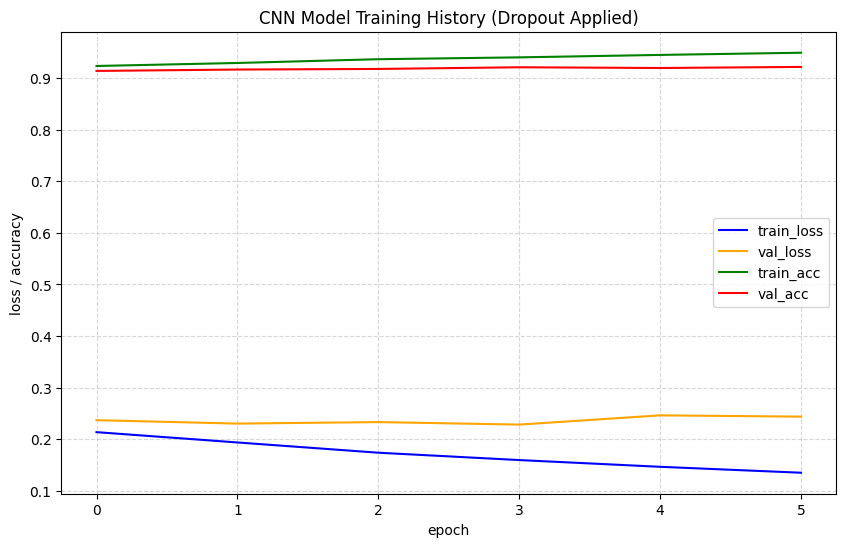

In [42]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.plot(history.history['loss'], label='train_loss', color='blue')
plt.plot(history.history['val_loss'], label='val_loss', color='orange')


plt.plot(history.history['accuracy'], label='train_acc', color='green')
plt.plot(history.history['val_accuracy'], label='val_acc', color='red')

# 그래프 설정
plt.xlabel('epoch')
plt.ylabel('loss / accuracy')
plt.title('CNN Model Training History (Dropout Applied)')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


--- Adam 옵티마이저 학습 시작 ---
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 47ms/step - accuracy: 0.7276 - loss: 0.7436 - val_accuracy: 0.8690 - val_loss: 0.3573
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.8643 - loss: 0.3755 - val_accuracy: 0.8947 - val_loss: 0.2835
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.8834 - loss: 0.3225 - val_accuracy: 0.9018 - val_loss: 0.2674
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.8961 - loss: 0.2868 - val_accuracy: 0.9084 - val_loss: 0.2494
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.9048 - loss: 0.2567 - val_accuracy: 0.9105 - val_loss: 0.2390
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.9128 - loss: 0.2360 - val_accuracy: 0.9139 - val_loss: 0.2307
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.9169 - loss: 0.2205 - val_accuracy: 0.9178 - val_loss: 0.2374
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms

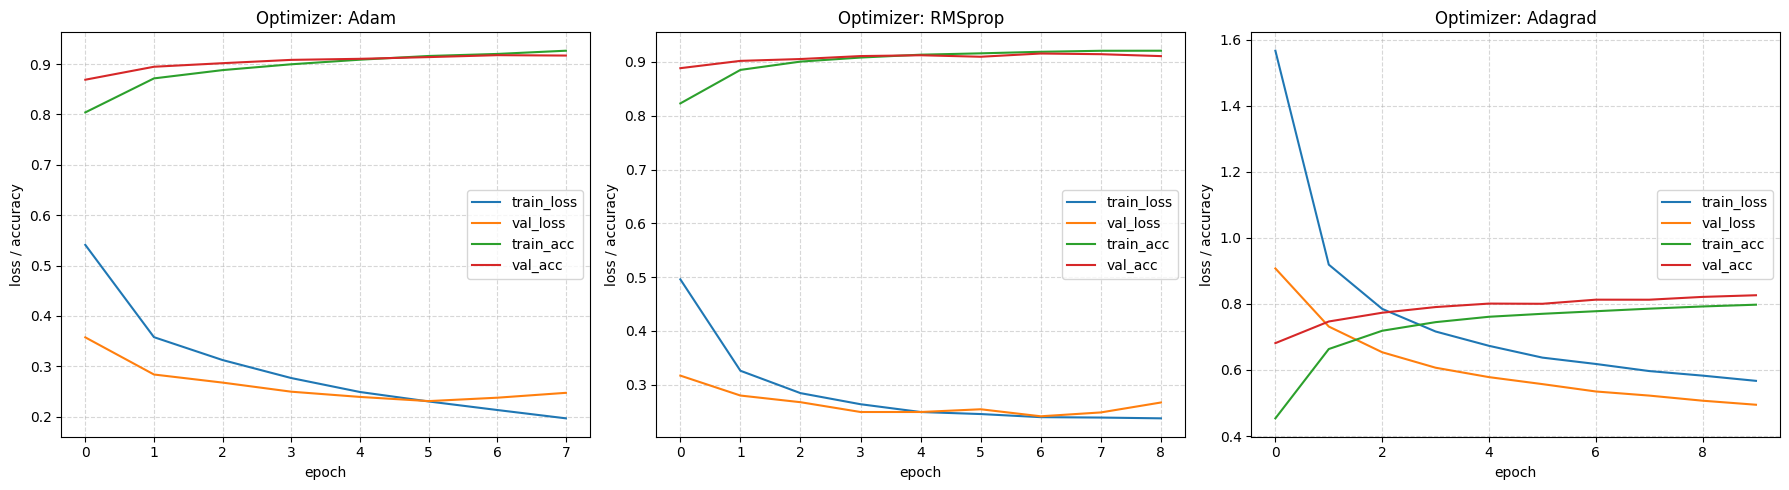

In [48]:
import matplotlib.pyplot as plt


optimizers = ['Adam', 'RMSprop', 'Adagrad']
histories = {}

for opt_name in optimizers:
    print(f"\n--- {opt_name} 옵티마이저 학습 시작 ---")


    model = conn_model_fn()
    model.compile(optimizer=opt_name.lower(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


    checkpoint_cb = keras.callbacks.ModelCheckpoint(f'best-{opt_name.lower()}-model.keras',
                                                    save_best_only=True)
    early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                      restore_best_weights=True)


    history = model.fit(train_scaled, train_target, epochs=10,
                        validation_data=(val_scaled, val_target),
                        verbose=1,
                        callbacks=[checkpoint_cb, early_stopping_cb])


    histories[opt_name] = history.history

plt.figure(figsize=(18, 5))

for i, opt_name in enumerate(optimizers):
    plt.subplot(1, 3, i+1)
    plt.plot(histories[opt_name]['loss'], label='train_loss')
    plt.plot(histories[opt_name]['val_loss'], label='val_loss')
    plt.plot(histories[opt_name]['accuracy'], label='train_acc')
    plt.plot(histories[opt_name]['val_accuracy'], label='val_acc')
    plt.title(f'Optimizer: {opt_name}')
    plt.xlabel('epoch')
    plt.ylabel('loss / accuracy')
    plt.legend(loc='center right')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
test_scaled = test_input.reshape(-1,28,28,1)/255.0

model = keras.models.load_model('best-cnn-model.keras')
model.evaluate(test_scaled, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9132 - loss: 0.2727


[0.25762635469436646, 0.911899983882904]

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


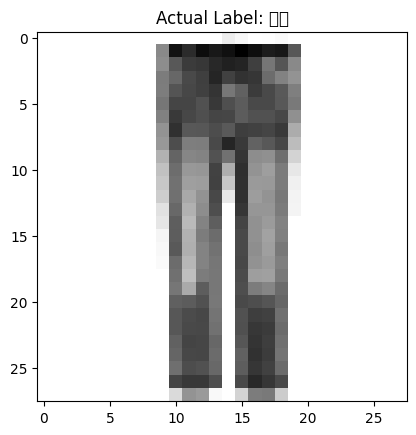

In [30]:
import numpy as np
import matplotlib.pyplot as plt

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클부츠']

plt.imshow(test_input[15], cmap='gray_r')
plt.title(f"Actual Label: {classes[test_target[15]]}")
plt.show()

In [34]:
preds = model.predict(test_scaled[15:16])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.0092736e-09 1.0000000e+00 1.3170527e-11 3.2980894e-09 8.7060925e-10
  3.3917761e-11 3.2948938e-10 1.2016211e-12 8.3595741e-11 1.3588650e-12]]


In [37]:
predicted_index = np.argmax(preds)
predicted_label = classes[predicted_index]

In [38]:
print(f"테스트 세트 15번 인덱스 예측 결과: {predicted_label}")
print(f"실제 정답 데이터: {classes[test_target[15]]}")

테스트 세트 15번 인덱스 예측 결과: 바지
실제 정답 데이터: 바지


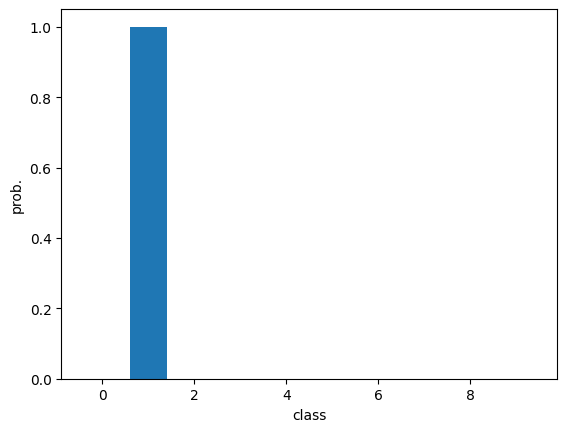

In [46]:
# 12번 항목 보충: 예측 확률 막대그래프
plt.bar(range(0, 10), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()